In [5]:
axes = ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your semicolon-delimited accelerometer data,
# parsing Time as floats
df = pd.read_csv('Accelerometer.csv', sep=';', dtype={'Time': float})
df.set_index('Time (s)', inplace=True)

axes = ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']

In [ ]:
# Quick peek
print(df.head())
print(df.info())
print(df.describe())

# --- 1) Line plots for each axis ---
for axis in axes:
    plt.figure(figsize=(10,4))
    plt.plot(df.index, df[axis], linestyle='-')
    plt.title(f'{axis.upper()} Axis over Time')
    plt.xlabel('Time')
    plt.ylabel(axis.upper())
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 2) Rolling standard deviation (window = 5 samples) ---
window = 5
roll_std = df.rolling(window=window).std()

for axis in axes:
    plt.figure(figsize=(10,4))
    plt.plot(roll_std.index, roll_std[axis], linestyle='-')
    plt.title(f'Rolling Std Dev (window={window}) of {axis.upper()}')
    plt.xlabel('Time')
    plt.ylabel('Std Dev')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- 3) Overall standard deviation bar chart ---
std_vals = df.std()
plt.figure(figsize=(6,4))
std_vals.plot(kind='bar')
plt.title('Overall Standard Deviation by Axis')
plt.xlabel('Axis')
plt.ylabel('Std Dev')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- 4) Boxplots for the distribution of each axis ---
plt.figure(figsize=(6,6))
plt.boxplot([df[axes[0]], df[axes[1]], df[axes[2]]], labels=axes)
plt.title('Boxplot of X, Y, Z')
plt.ylabel('Value')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# --- assume df is already loaded, indexed by Time: df = pd.read_csv(...).set_index('Time') ---

# 1. Detecting Outliers (Sect. 3.1)  
# --------------------------------------------------

# 1.1 Chauvenet’s Criterion
def chauvenet(df, col):
    data = df[col].values
    mean, std = data.mean(), data.std()
    # probability of each point in fitted normal
    probs = 2*(1 - norm.cdf(np.abs(data-mean)/std))
    N = data.size
    criterion = 1.0/(2*N)
    return df[probs < criterion]

outliers_chauvenet = {axis: chauvenet(df, axis) for axis in axes}


# 1.2 Gaussian Mixture Model
def mixture_outliers(df, cols, n_components=2, threshold=0.01):
    X = df[cols].values
    gm = GaussianMixture(n_components=n_components, random_state=0).fit(X)
    probs = np.exp(gm.score_samples(X))
    cutoff = np.percentile(probs, 5)
    return df[probs < cutoff]

outliers_mixture = mixture_outliers(df, axes, n_components=3, threshold=0.02)


# 1.3 Global Distance-Based
def global_distance_outliers(df, cols, radius):
    X = df[cols].values
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    # distance to the nearest neighbor (excluding itself)
    distances, _ = nbrs.kneighbors(X)
    # distances[:,1] is distance to the first neighbor
    return df[distances[:,1] > radius]

outliers_global = global_distance_outliers(df, axes, radius=2.0)


# 1.4 Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels = lof.fit_predict(df[axes])
outliers_lof = df[labels < 0]


# 2. Imputing Missing Values (Sect. 3.2)  
# --------------------------------------------------

# (Assume df_missing has NaNs)

# 2.1 Simple Strategies
#   - Mean Imputation
mean_imp = SimpleImputer(strategy='mean')
df_mean_imp = pd.DataFrame(mean_imp.fit_transform(df), 
                           index=df.index, columns=df.columns)

#   - Interpolation (linear for time‐series)
df_interp = df.interpolate(method='linear')

# 2.2 K-Nearest Neighbors Imputation
knn_imp = KNNImputer(n_neighbors=5)
df_knn_imp = pd.DataFrame(knn_imp.fit_transform(df), 
                          index=df.index, columns=df.columns)

# 2.3 Model-Based Imputation (Iterative)
iter_imp = IterativeImputer(estimator=BayesianRidge(), random_state=0)
df_iter_imp = pd.DataFrame(iter_imp.fit_transform(df), 
                           index=df.index, columns=df.columns)


# --- Quick summaries ---
print("Chauvenet outliers per axis:", {k: v.shape[0] for k,v in outliers_chauvenet.items()})
print("Mixture-model outliers:", outliers_mixture.shape[0])
print("Global-distance outliers:", outliers_global.shape[0])
print("LOF outliers:", outliers_lof.shape[0])

print("\nAfter imputation:")
print("Mean-imputed NA count:", df_mean_imp.isna().sum().sum())
print("Interpolated NA count:", df_interp.isna().sum().sum())
print("KNN-imputed NA count:", df_knn_imp.isna().sum().sum())
print("Iterative-imputed NA count:", df_iter_imp.isna().sum().sum())


Chauvenet outliers per axis: {'Acceleration x (m/s^2)': 0, 'Acceleration y (m/s^2)': 0, 'Acceleration z (m/s^2)': 6}
Mixture-model outliers: 1839
Global-distance outliers: 21
LOF outliers: 1839

After imputation:
Mean-imputed NA count: 0
Interpolated NA count: 0
KNN-imputed NA count: 0
Iterative-imputed NA count: 0


In [ ]:
!pip3 install scikit-learn

In [ ]:
def mixture_outliers_imputation(df, cols, n_components=2, threshold=0.01):
    X = df[cols].values
    gm = GaussianMixture(n_components=n_components, random_state=0).fit(X)
    probs = np.exp(gm.score_samples(X))
    cutoff = np.percentile(probs, 5)
    
    df_zeroed = df.copy()
    for axis in axes:
        df_zeroed.loc[probs<cutoff, axis] = df_zeroed[axis].mean()

    # for axis in cols:
    axis = axes[2]
    plt.figure(figsize=(10,4))
    plt.plot(df_zeroed.index, df_zeroed[axis], linestyle='-')
    plt.title(f'{axis.upper()} Axis over Time')
    plt.xlabel('Time')
    plt.ylabel(axis.upper())
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return df[probs < cutoff]
mixture_outliers_imputation(df, axes)

In [9]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# 1) Load your data
df = pd.read_csv('Accelerometer.csv', sep=';', dtype={'Time': float})
df.set_index('Time (s)', inplace=True)

# 2) Detect outliers via Gaussian Mixture
X = df[axes].values
gm = GaussianMixture(n_components=2, random_state=0).fit(X)

# get sample densities
log_probs = gm.score_samples(X)
probs     = np.exp(log_probs)

# choose bottom 5% as outliers
cutoff = np.percentile(probs, 5)
outlier_mask = probs < cutoff

# create a “clean” copy with outliers zeroed → NaN’d for imputation
df_clean = df.copy()
df_clean.loc[outlier_mask, axes] = np.nan

print(f"Detected {outlier_mask.sum()} outlier rows via GMM.")

# 3) Imputation methods
# ----------------------

# 3.1 Mean Imputation (simple global mean)
mean_imp = SimpleImputer(strategy='mean')
df_mean_imp = pd.DataFrame(
    mean_imp.fit_transform(df_clean),
    index=df_clean.index,
    columns=df_clean.columns
)

# 3.2 Linear Interpolation (time‐ordered)
df_interp = df_clean.interpolate(method='linear')

# 3.3 K-Nearest Neighbors Imputation
knn_imp = KNNImputer(n_neighbors=5)
df_knn_imp = pd.DataFrame(
    knn_imp.fit_transform(df_clean),
    index=df_clean.index,
    columns=df_clean.columns
)

# 3.4 Iterative (Model-Based) Imputation
iter_imp = IterativeImputer(estimator=BayesianRidge(), random_state=0)
df_iter_imp = pd.DataFrame(
    iter_imp.fit_transform(df_clean),
    index=df_clean.index,
    columns=df_clean.columns
)

# 4) Summarize missing‐value counts after each method
print("\nMissing after detection (should equal # outlier rows × 3 axes):")
print(df_clean.isna().sum())

print("\nMissing after mean imputation:")
print(df_mean_imp.isna().sum())

print("\nMissing after linear interpolation:")
print(df_interp.isna().sum())

print("\nMissing after KNN imputation:")
print(df_knn_imp.isna().sum())

print("\nMissing after iterative (model‐based) imputation:")
print(df_iter_imp.isna().sum())

# Optional: Compare a sample of original, clean, and each imputed
sample_times = df_clean.index[outlier_mask][:5]
comparison = pd.DataFrame({
    'original_x':    df.loc[sample_times, axes[0]],
    'clean_x (NaN)': df_clean.loc[sample_times, axes[0]],
    'mean_imp_x':    df_mean_imp.loc[sample_times, axes[0]],
    'interp_x':      df_interp.loc[sample_times, axes[0]],
    'knn_imp_x':     df_knn_imp.loc[sample_times, axes[0]],
    'iter_imp_x':    df_iter_imp.loc[sample_times, axes[0]],
})
print("\nExample imputation on first few outlier timestamps:")
print(comparison)


Detected 1839 outlier rows via GMM.

Missing after detection (should equal # outlier rows × 3 axes):
Acceleration x (m/s^2)    1839
Acceleration y (m/s^2)    1839
Acceleration z (m/s^2)    1839
dtype: int64

Missing after mean imputation:
Acceleration x (m/s^2)    0
Acceleration y (m/s^2)    0
Acceleration z (m/s^2)    0
dtype: int64

Missing after linear interpolation:
Acceleration x (m/s^2)    0
Acceleration y (m/s^2)    0
Acceleration z (m/s^2)    0
dtype: int64

Missing after KNN imputation:
Acceleration x (m/s^2)    0
Acceleration y (m/s^2)    0
Acceleration z (m/s^2)    0
dtype: int64

Missing after iterative (model‐based) imputation:
Acceleration x (m/s^2)    0
Acceleration y (m/s^2)    0
Acceleration z (m/s^2)    0
dtype: int64

Example imputation on first few outlier timestamps:
          original_x  clean_x (NaN)  mean_imp_x  interp_x  knn_imp_x  \
Time (s)                                                               
0.050608    3.889979            NaN    7.321041  4.112790

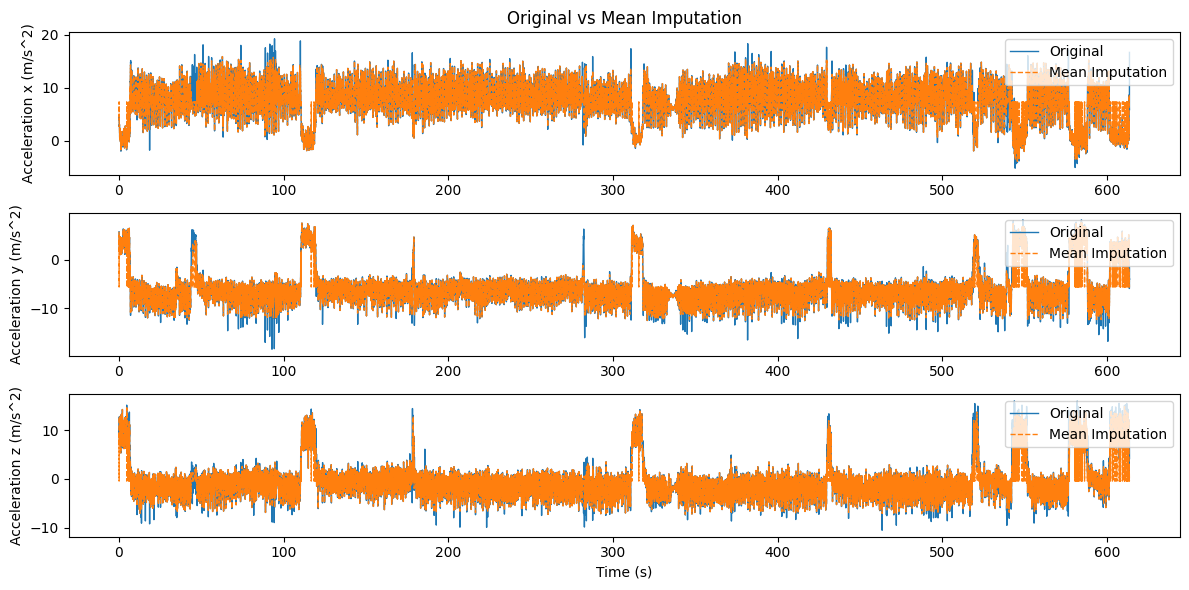

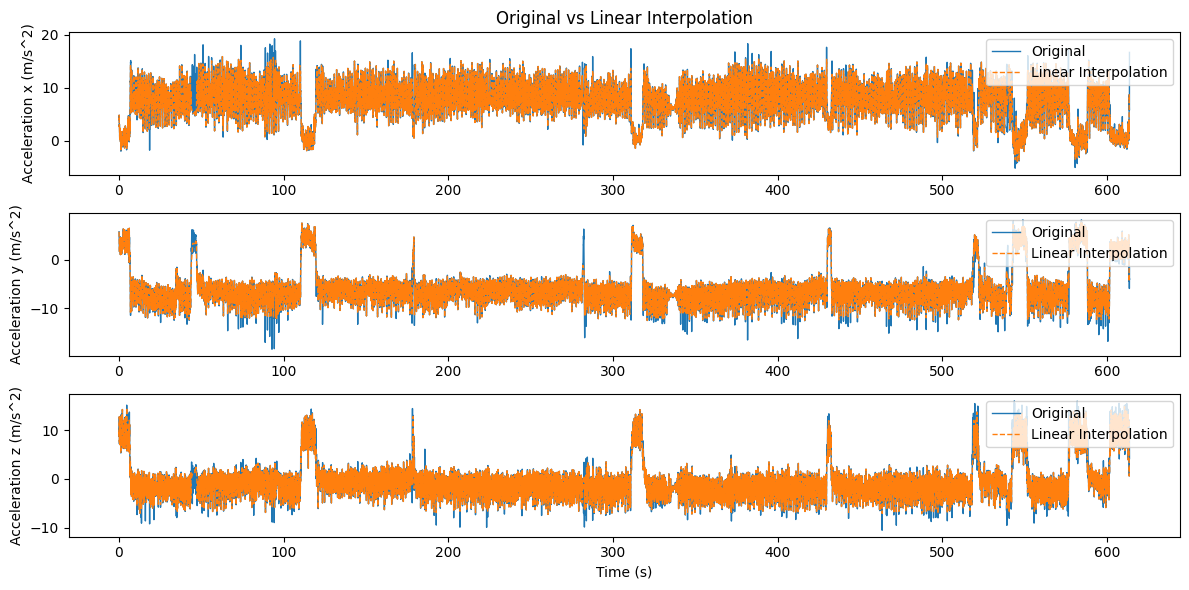

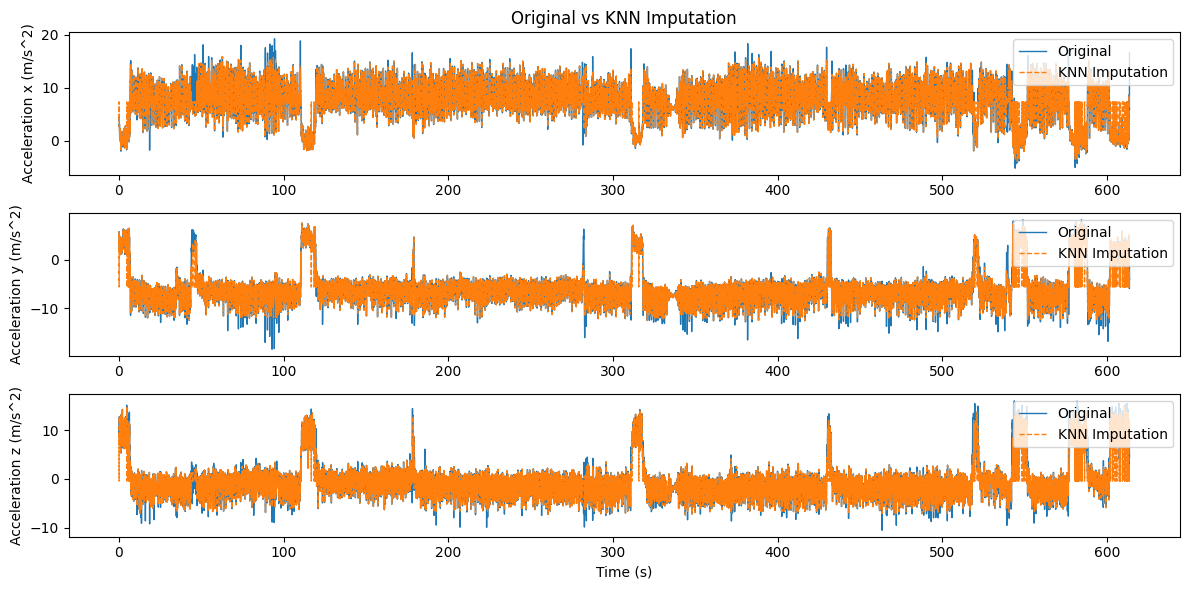

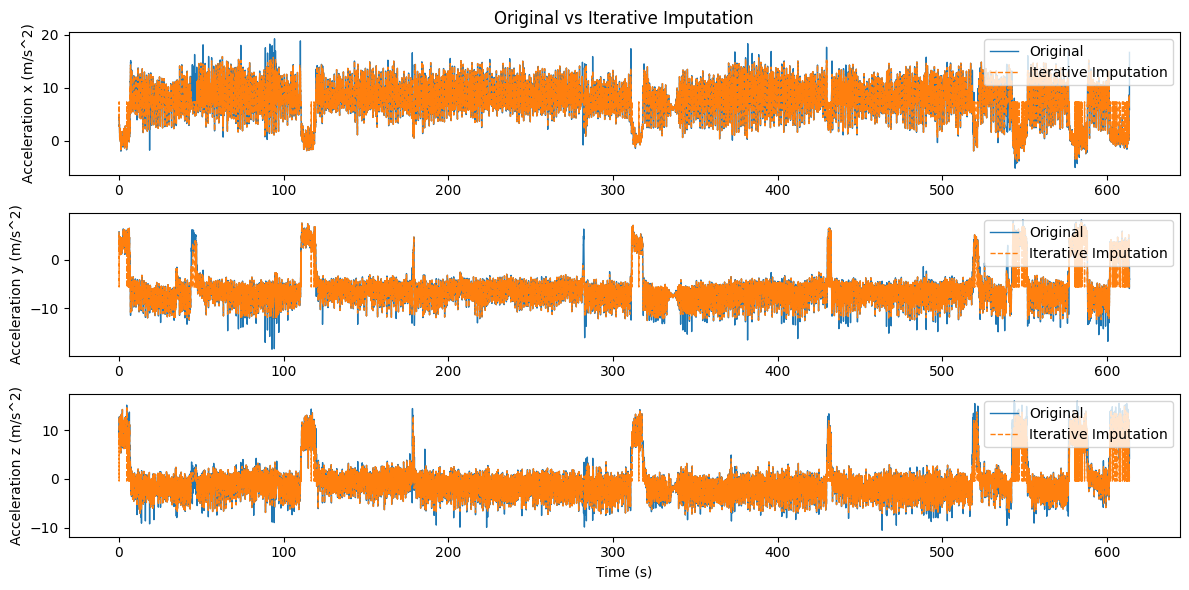

In [11]:
import matplotlib.pyplot as plt

imputed_dfs = {
    'Mean Imputation': df_mean_imp,
    'Linear Interpolation': df_interp,
    'KNN Imputation': df_knn_imp,
    'Iterative Imputation': df_iter_imp
}

for method, df_imp in imputed_dfs.items():
    plt.figure(figsize=(12, 6))
    for i, axis in enumerate(axes, 1):
        ax = plt.subplot(len(axes), 1, i)
        ax.plot(df.index,     df[axis],     label='Original', linewidth=1)
        ax.plot(df_imp.index, df_imp[axis], label=method,   linestyle='--', linewidth=1)
        ax.set_ylabel(axis)
        if i == 1:
            ax.set_title(f'Original vs {method}')
        if i == len(axes):
            ax.set_xlabel('Time (s)')
        ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
